In [50]:
import numpy as np  
import matplotlib.pyplot as plt 
import random
from random import sample
import astroML.stats

The weather tomorrow depends only on the weather today

Proposal probability:


$$p({\rm clear \; tomorrow} \, |\,  {\rm cloudy \; today}) = 0.5,$$



$$p({\rm cloudy \; tomorrow} \, |\, {\rm cloudy \; today}) = 0.5.$$



$$p({\rm cloudy \; tomorrow} \, |\, {\rm clear \; today}) = 0.1,$$



$$p({\rm clear \; tomorrow} \, |\, {\rm clear \; today}) = 0.9.$$

In [65]:
#0 is a cloudy day
#1 is a sunny day 

N=100000

def Markov ():
    
    today=0                #cloudy day 
    cloudy_counts=0
    sunny_counts=0


    #Evolution of the probability for different N 
    Ps=[]              
    Pc=[]


    for i in range(1,N):

        if today ==0:
            p=np.random.uniform(0,1)
            if p<=0.5:
                today=0
            else :
                today=1
        else : 
            p=np.random.uniform(0,1)
            if p<=0.1:
                today=0
            else :
                today=1
        
        if today ==0:
            cloudy_counts+=1
        else :
            sunny_counts+=1
        
        Ps.append(sunny_counts/i)
        Pc.append(cloudy_counts/i)

    return Ps,Pc



After enough days we reach stationarity

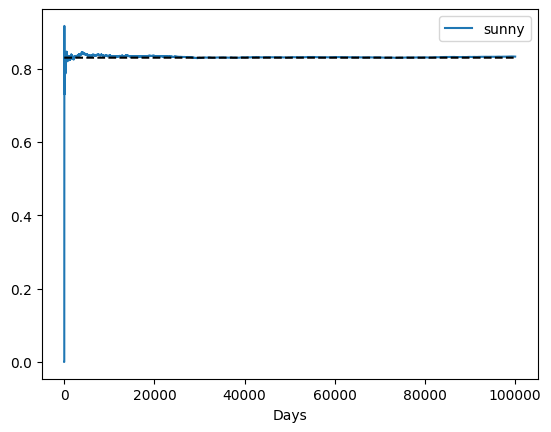

In [ ]:
x=np.linspace(1,N,N-1)
Ps=Markov()[0]
plt.plot(x,Ps, label= "sunny")
plt.plot(x,0.83*np.ones(len(x)), '--', color='black') #theoretical value
plt.xlabel("Days")
plt.legend()
plt.show()

Histogram with ALL the points

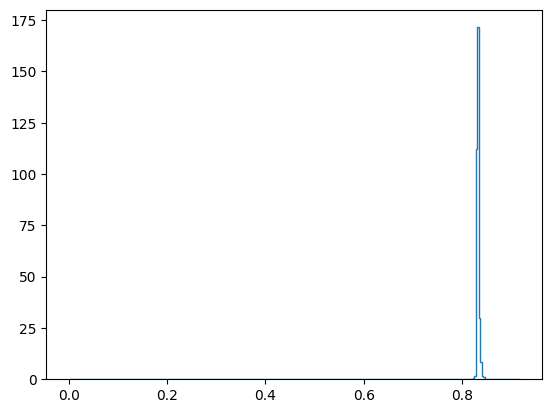

In [67]:
plt.hist(Ps, 300, density=True, histtype='step'); #distribution of P(sunny)

In [68]:
print(np.median(Ps))
print(astroML.stats.sigmaG(Ps))
print(min(Ps),max(Ps))              #spread of the distribution

0.8314333829911263
0.0014485493212901272
0.0 0.9166666666666666


### Burn-in phase exploration

Let's cut 20000 points

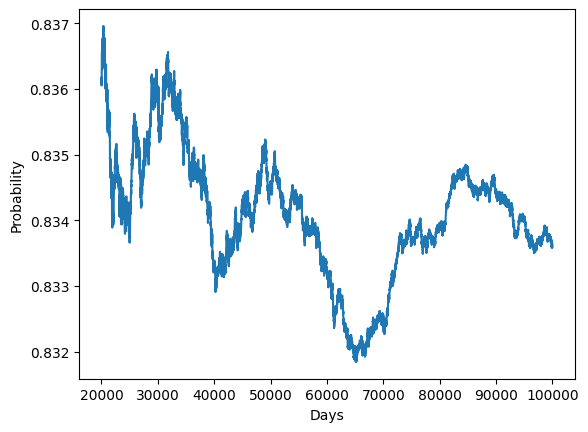

In [55]:
burn = 20000
plt.plot(x[burn:],Ps[burn:])
plt.xlabel("Days")
plt.ylabel("Probability")
plt.show()


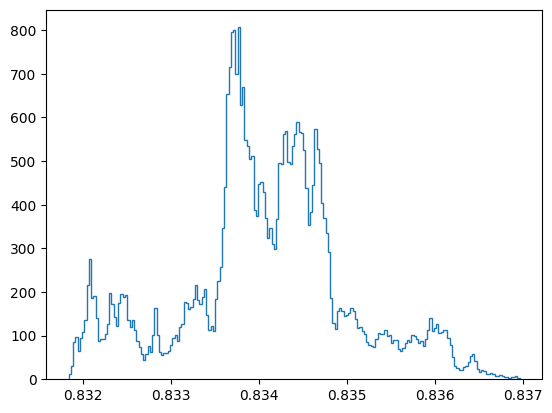

In [56]:
plt.hist(Ps[burn:], 200, density=True, histtype='step'); #distribution of P(sunny)

In [57]:
print(np.median(Ps[burn:]))
print(astroML.stats.sigmaG(Ps[burn:]))
print(min(Ps[burn:]),max(Ps[burn:]))

0.8340700588304886
0.0007210308934338958
0.8318411474730101 0.8369623986237404


### Selection of different parts


In [81]:
Ps1= Ps[40000:60000]
Ps2= Ps[60000:80000]
Ps3= Ps[80000:100000]

print("First slicing %.3f" %(np.mean(Ps1)))
print("Second slicing %.3f" %(np.mean(Ps2)))
print("Third slicing %.3f" %(np.mean(Ps3)))

First slicing 0.831
Second slicing 0.831
Third slicing 0.832


It is stable!


### Performing the chain different times

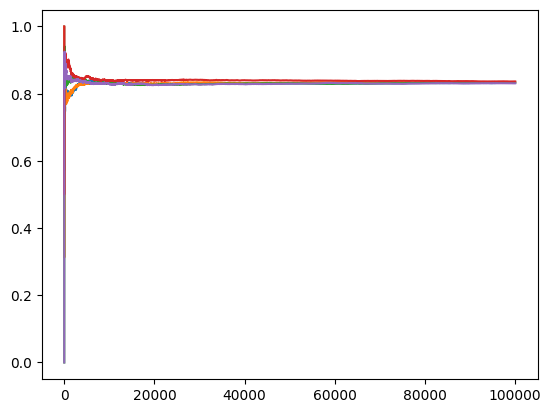

In [82]:
#5 different chains

Ps=np.array([Markov()[0] for i in range(5)])
for i in range(5):
    plt.plot(x,Ps[i], label= "sample %d" %i)

Focusing on the differences in the burn-in period

(0.7, 0.95)

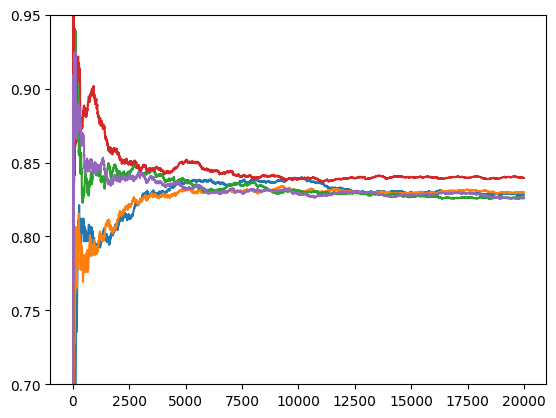

In [85]:
for i in range(5):
    plt.plot(x[:20000],Ps[i][:20000], label= "sample %d" %i)
plt.ylim(0.7,.95)